## Financial Data Analysis with PySpark Part 1

In [12]:
from pyspark.sql import SparkSession, functions
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
spark = SparkSession.builder.appName('stock_price_analysis').getOrCreate()

In [14]:
df = spark.read.csv('World-Stock-Prices-Dataset.csv', header=True, inferSchema=True)

In [16]:
df.printSchema()

root
 |-- Date: timestamp (nullable = true)
 |-- Open: double (nullable = true)
 |-- High: double (nullable = true)
 |-- Low: double (nullable = true)
 |-- Close: double (nullable = true)
 |-- Volume: double (nullable = true)
 |-- Brand_Name: string (nullable = true)
 |-- Ticker: string (nullable = true)
 |-- Industry_Tag: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- Dividends: double (nullable = true)
 |-- Stock Splits: double (nullable = true)
 |-- Capital Gains: double (nullable = true)



In [17]:
df.columns

['Date',
 'Open',
 'High',
 'Low',
 'Close',
 'Volume',
 'Brand_Name',
 'Ticker',
 'Industry_Tag',
 'Country',
 'Dividends',
 'Stock Splits',
 'Capital Gains']

In [18]:
from pyspark.sql.types import *
data_schema = [
    StructField('Date', DateType(), True),
    StructField('Open', DoubleType(), True),
    StructField('High', DoubleType(), True),
    StructField('Low', DoubleType(), True),
    StructField('Close', DoubleType(), True),
    StructField('Volume', DoubleType(), True),
    StructField('Brand_Name', StringType(), True),
    StructField('Ticker', StringType(), True),
    StructField('Industry_Tag', StringType(), True),
    StructField('Country', StringType(), True),
    StructField('Dividends', DoubleType(), True),
    StructField('Stock Splits', DoubleType(), True),
    StructField('Capital Gains', DoubleType(), True),
]

In [19]:
struc = StructType(fields=data_schema)

In [20]:
df = spark.read.csv('World-Stock-Prices-Dataset.csv', header=True, schema=struc)

In [21]:
df.show(5)

+----------+------------------+------------------+-----------------+------------------+-----------+----------+------+------------+-------+---------+------------+-------------+
|      Date|              Open|              High|              Low|             Close|     Volume|Brand_Name|Ticker|Industry_Tag|Country|Dividends|Stock Splits|Capital Gains|
+----------+------------------+------------------+-----------------+------------------+-----------+----------+------+------------+-------+---------+------------+-------------+
|2025-07-03| 6.630000114440918| 6.739999771118164|6.614999771118164| 6.639999866485596|  4209664.0|   peloton|  PTON|     fitness|    usa|      0.0|         0.0|         NULL|
|2025-07-03|            106.75|108.37000274658205|106.3301010131836|107.33999633789062|   560190.0|     crocs|  CROX|    footwear|    usa|      0.0|         0.0|         NULL|
|2025-07-03|122.62999725341795| 123.0500030517578|121.5500030517578|121.93000030517578|    36600.0|    adidas| ADDYY|   

In [22]:
df.printSchema()

root
 |-- Date: date (nullable = true)
 |-- Open: double (nullable = true)
 |-- High: double (nullable = true)
 |-- Low: double (nullable = true)
 |-- Close: double (nullable = true)
 |-- Volume: double (nullable = true)
 |-- Brand_Name: string (nullable = true)
 |-- Ticker: string (nullable = true)
 |-- Industry_Tag: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- Dividends: double (nullable = true)
 |-- Stock Splits: double (nullable = true)
 |-- Capital Gains: double (nullable = true)



In [23]:
df.columns

['Date',
 'Open',
 'High',
 'Low',
 'Close',
 'Volume',
 'Brand_Name',
 'Ticker',
 'Industry_Tag',
 'Country',
 'Dividends',
 'Stock Splits',
 'Capital Gains']

In [24]:
df.describe().show()

+-------+------------------+-----------------+------------------+------------------+--------------------+----------+------+------------+-------+--------------------+--------------------+-------------+
|summary|              Open|             High|               Low|             Close|              Volume|Brand_Name|Ticker|Industry_Tag|Country|           Dividends|        Stock Splits|Capital Gains|
+-------+------------------+-----------------+------------------+------------------+--------------------+----------+------+------------+-------+--------------------+--------------------+-------------+
|  count|            310122|           310122|            310122|            310122|              310122|    310122|310122|      310122| 310122|              310122|              310122|            2|
|   mean| 76.32543131510262|77.19801134617839| 75.43458576107446| 76.33803235037772|2.2709366044795275E7|      NULL|  NULL|        NULL|   NULL|0.003643122306705...|8.745251211431723E-4|          

In [25]:
df.describe().toPandas()

D:\miniconda3\envs\pyspark_env\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


,summary,Open,High,Low,Close,Volume,Brand_Name,Ticker,Industry_Tag,Country,Dividends,Stock Splits,Capital Gains
0,count,310122,310122,310122,310122,310122,310122,310122,310122,310122,310122,310122,2
1,mean,76.32543131510262,77.19801134617839,75.43458576107446,76.33803235037772,2.2709366044795275E7,NaN,NaN,NaN,NaN,0.0036431223067050996,8.745251211431723E-4,0.0
2,stddev,141.68407014441587,143.2241092406135,140.06361661099442,141.67912891948237,8.565743780222397E7,NaN,NaN,NaN,NaN,0.06990542493638914,0.11543439610726967,0.0
3,min,0.0,0.0,0.0,0.1988611817359924,0.0,3m,AAPL,apparel,canada,0.0,0.0,0.0
4,max,3445.580078125,3463.070068359375,3370.0,3427.610107421875,7.4216408E9,zoominfo,ZM,technology,usa,15.0,50.0,0.0


In [26]:
df.count()

310122

In [27]:
df.distinct().count()

310122

In [29]:
df.select(['Open', 'High', 'Low', 'Close', 'Volume']).describe().show()

+-------+------------------+-----------------+------------------+------------------+--------------------+
|summary|              Open|             High|               Low|             Close|              Volume|
+-------+------------------+-----------------+------------------+------------------+--------------------+
|  count|            310122|           310122|            310122|            310122|              310122|
|   mean| 76.32543131510262|77.19801134617839| 75.43458576107446| 76.33803235037772|2.2709366044795275E7|
| stddev|141.68407014441587|143.2241092406135|140.06361661099442|141.67912891948237| 8.565743780222397E7|
|    min|               0.0|              0.0|               0.0|0.1988611817359924|                 0.0|
|    max|    3445.580078125|3463.070068359375|            3370.0| 3427.610107421875|         7.4216408E9|
+-------+------------------+-----------------+------------------+------------------+--------------------+



In [30]:
df.groupBy('Industry_Tag').count().show()

+------------------+-----+
|      Industry_Tag|count|
+------------------+-----+
|      social media| 1618|
|        automotive|24867|
|           finance|22210|
|        technology|66957|
|financial services| 2380|
|              food|11415|
|           apparel|21069|
|       hospitality|10633|
|      luxury goods| 4939|
|     manufacturing| 6470|
|   food & beverage|19409|
|             music| 1879|
|            retail|25842|
|         logistics| 6469|
|    consumer goods|19407|
|        e-commerce| 9072|
|        healthcare| 6470|
|          aviation|11098|
|          footwear|11407|
|     entertainment|12342|
+------------------+-----+
only showing top 20 rows


In [31]:
by_tag = df.select(['Industry_Tag', 'Open', 'Close']).groupBy('Industry_Tag').mean().collect()

In [32]:
by_tag

[Row(Industry_Tag='social media', avg(Open)=34.78246475769062, avg(Close)=34.80021632528128),
 Row(Industry_Tag='automotive', avg(Open)=58.88270088469111, avg(Close)=58.88042419762223),
 Row(Industry_Tag='finance', avg(Open)=102.20609774369709, avg(Close)=102.23462674863593),
 Row(Industry_Tag='technology', avg(Open)=61.110692913366975, avg(Close)=61.11963814882714),
 Row(Industry_Tag='financial services', avg(Open)=81.74041433694984, avg(Close)=81.68226884513342),
 Row(Industry_Tag='food', avg(Open)=326.2408207226715, avg(Close)=326.26303235833916),
 Row(Industry_Tag='apparel', avg(Open)=41.117747523910836, avg(Close)=41.088793636664036),
 Row(Industry_Tag='hospitality', avg(Open)=90.41661992648886, avg(Close)=90.45551435148953),
 Row(Industry_Tag='luxury goods', avg(Open)=60.628982721223736, avg(Close)=60.69265501092238),
 Row(Industry_Tag='manufacturing', avg(Open)=87.80478713176251, avg(Close)=87.80966032549992),
 Row(Industry_Tag='food & beverage', avg(Open)=49.52590240411639, avg

In [34]:
print(['Industry_Tag', 'Open', 'Close'])
for row in by_tag:
    print(list(row), end='\n')

['Industry_Tag', 'Open', 'Close']
['social media', 34.78246475769062, 34.80021632528128]
['automotive', 58.88270088469111, 58.88042419762223]
['finance', 102.20609774369709, 102.23462674863593]
['technology', 61.110692913366975, 61.11963814882714]
['financial services', 81.74041433694984, 81.68226884513342]
['food', 326.2408207226715, 326.26303235833916]
['apparel', 41.117747523910836, 41.088793636664036]
['hospitality', 90.41661992648886, 90.45551435148953]
['luxury goods', 60.628982721223736, 60.69265501092238]
['manufacturing', 87.80478713176251, 87.80966032549992]
['food & beverage', 49.52590240411639, 49.54047357935927]
['music', 231.29417280163645, 231.4769716572419]
['retail', 98.73165892599584, 98.77241724824104]
['logistics', 126.97905133521171, 127.00358105575602]
['consumer goods', 47.48126367520415, 47.50127972392866]
['e-commerce', 49.06879360230091, 49.066015759910044]
['healthcare', 78.64787411118643, 78.66262075904716]
['aviation', 27.8077321982467, 27.7969722510845]
['

In [35]:
tag_df = df.select(['Industry_Tag', 'Open', 'Close']).groupBy('Industry_Tag').mean().toPandas()

D:\miniconda3\envs\pyspark_env\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


In [36]:
tag_df

,Industry_Tag,avg(Open),avg(Close)
0,social media,34.782465,34.800216
1,automotive,58.882701,58.880424
2,finance,102.206098,102.234627
3,technology,61.110693,61.119638
4,financial services,81.740414,81.682269
5,food,326.240821,326.263032
6,apparel,41.117748,41.088794
7,hospitality,90.416620,90.455514
8,luxury goods,60.628983,60.692655
9,manufacturing,87.804787,87.809660


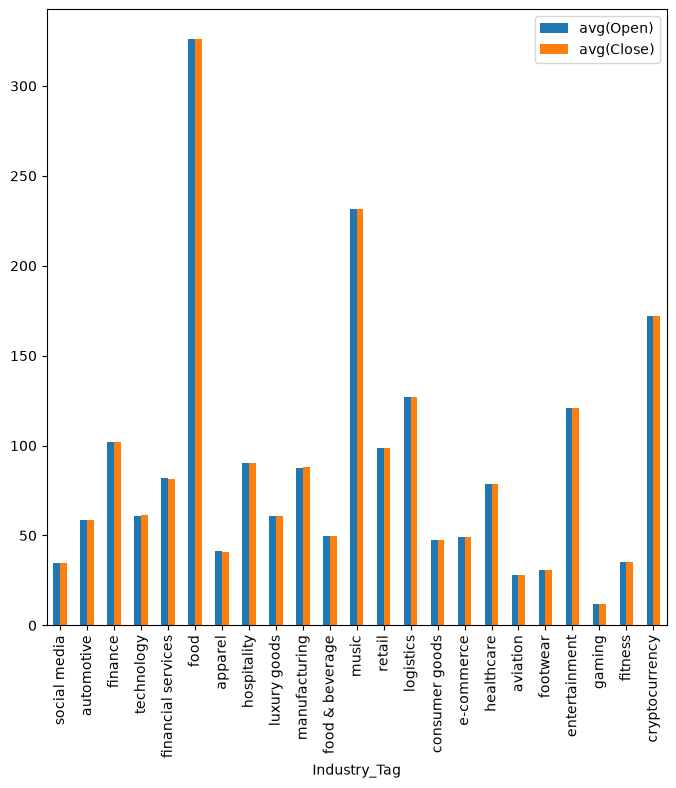

In [39]:
tag_df.plot(kind='bar', x='Industry_Tag', y=tag_df.columns.tolist()[1:],
           figsize=(8,8));

In [41]:
country_df = df.select(['Country', 'Open', 'Close']).groupBy('country').mean().toPandas()

D:\miniconda3\envs\pyspark_env\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


In [44]:
country_df

,country,avg(Open),avg(Close)
0,japan,44.267453,44.262858
1,switzerland,28.828441,28.840045
2,netherlands,26.542670,26.549592
3,canada,50.920812,50.930384
4,france,37.066948,37.101754
5,germany,49.468276,49.435015
6,usa,86.275123,86.291699


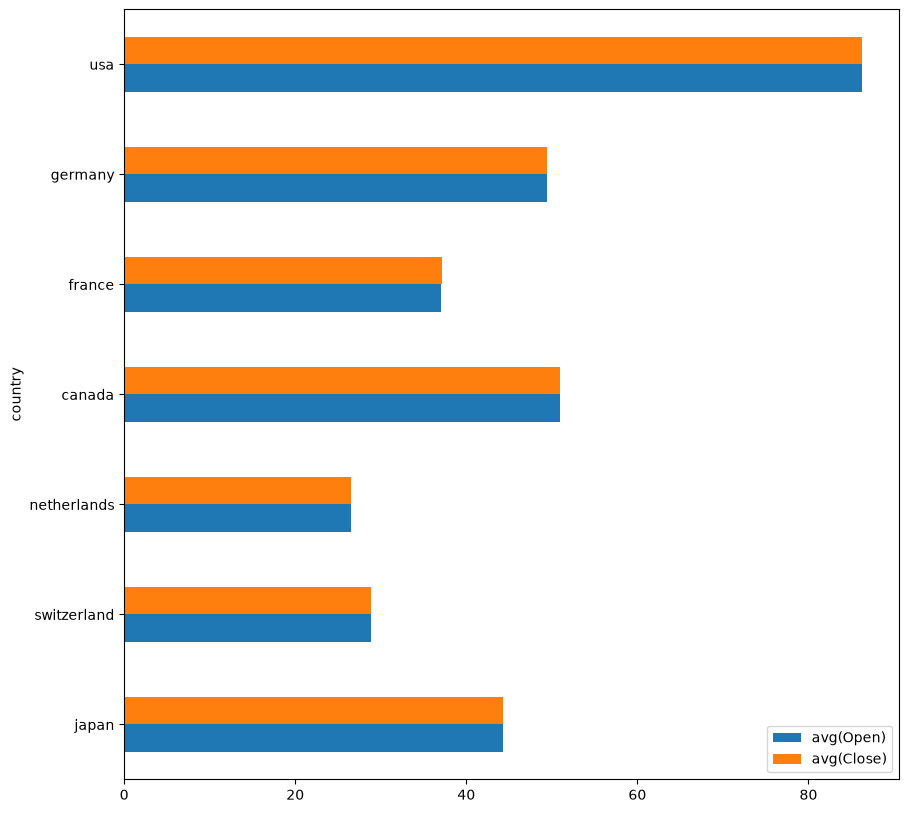

In [48]:
country_df.plot(kind='barh', x='country', y=country_df.columns.tolist()[1:], figsize=(10,10));